In [3]:
# ASSIGNMENT PYTHON ML PART 2.

# Uploading the dataset into pandas for quick data check of file.

import pandas as pd

df = pd.read_csv("household_power_consumption.txt", sep=';', low_memory=False)   #   <----ENTER CORRECT PATH

print(df.head())
print('-' * 40)
print(df.shape)
print('-' * 40)
print(df.columns)
print('-' * 40)
print(df.dtypes)
print('-' * 40)
print(df.isnull().sum())
print('-' * 40)
print(df.duplicated().sum())

         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  
----------------------------------------
(2075259, 9)
----------------------------------------
Index(['Date', 'Time', 'Global_act

In [4]:
#1.1 Data Preparation - There are missing values, probably with "?" but not null. Lets try find them

print((df == '?').sum())

Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3               0
dtype: int64


In [5]:
#1.2 Data Preparation - Checking incomplete observations

missing_rows = df[df['Global_active_power'] == '?']

print(missing_rows.head())
print('-' * 40)
print(missing_rows.shape)
print('-' * 40)
print(missing_rows['Sub_metering_3'].isnull().sum())

             Date      Time Global_active_power Global_reactive_power Voltage  \
6839   21/12/2006  11:23:00                   ?                     ?       ?   
6840   21/12/2006  11:24:00                   ?                     ?       ?   
19724  30/12/2006  10:08:00                   ?                     ?       ?   
19725  30/12/2006  10:09:00                   ?                     ?       ?   
41832   14/1/2007  18:36:00                   ?                     ?       ?   

      Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
6839                 ?              ?              ?             NaN  
6840                 ?              ?              ?             NaN  
19724                ?              ?              ?             NaN  
19725                ?              ?              ?             NaN  
41832                ?              ?              ?             NaN  
----------------------------------------
(25979, 9)
-----------------------------------

In [6]:
#1.3 Data Preparation - Converting measurement columns to numeric values

measurement_cols = [
    'Global_active_power','Global_reactive_power','Voltage','Global_intensity',
    'Sub_metering_1','Sub_metering_2','Sub_metering_3'
                    ]

df[measurement_cols] = df[measurement_cols].apply(
    pd.to_numeric,
    errors='coerce')

print(df.dtypes)
print('-' * 40)
print(df.isnull().sum())

Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object
----------------------------------------
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [7]:
#1.4 Data Preparation - Removing incomplete observations

df = df.dropna().copy()

print(df.shape)
print('-' * 40)
print(df.isnull().sum())

(2049280, 9)
----------------------------------------
Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [8]:
#1.5 Data Preparation - Creating new Datetime variable

df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True)

print(df[['Date', 'Time', 'Datetime']].head())
print('-' * 40)
print(df['Datetime'].min())
print(df['Datetime'].max())
print('-' * 40)
print(df.dtypes)

         Date      Time            Datetime
0  16/12/2006  17:24:00 2006-12-16 17:24:00
1  16/12/2006  17:25:00 2006-12-16 17:25:00
2  16/12/2006  17:26:00 2006-12-16 17:26:00
3  16/12/2006  17:27:00 2006-12-16 17:27:00
4  16/12/2006  17:28:00 2006-12-16 17:28:00
----------------------------------------
2006-12-16 17:24:00
2010-11-26 21:02:00
----------------------------------------
Date                                str
Time                                str
Global_active_power             float64
Global_reactive_power           float64
Voltage                         float64
Global_intensity                float64
Sub_metering_1                  float64
Sub_metering_2                  float64
Sub_metering_3                  float64
Datetime                 datetime64[us]
dtype: object


In [9]:
#1.6 Data Preparation - Final time features for exploratory analysis

df = df.sort_values('Datetime').copy()

df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Hour'] = df['Datetime'].dt.hour
df['Day'] = df['Datetime'].dt.day_name()

print(df[['Datetime', 'Year', 'Month', 'Hour', 'Day']].head())
print('-' * 40)
print(df.shape)

             Datetime  Year  Month  Hour       Day
0 2006-12-16 17:24:00  2006     12    17  Saturday
1 2006-12-16 17:25:00  2006     12    17  Saturday
2 2006-12-16 17:26:00  2006     12    17  Saturday
3 2006-12-16 17:27:00  2006     12    17  Saturday
4 2006-12-16 17:28:00  2006     12    17  Saturday
----------------------------------------
(2049280, 14)


In [10]:
#2.1 Exploratory and Statistical Analysis - Daily average Global Active Power

daily_power = (
    df.set_index('Datetime')['Global_active_power']
    .resample('D')
    .mean()
    .reset_index())

print(daily_power.head())
print('-' * 40)
print(daily_power.shape)

    Datetime  Global_active_power
0 2006-12-16             3.053475
1 2006-12-17             2.354486
2 2006-12-18             1.530435
3 2006-12-19             1.157079
4 2006-12-20             1.545658
----------------------------------------
(1442, 2)


In [11]:
#2.2 Exploratory and Statistical Analysis - Checking completeness of daily observations

daily_counts = (
    df.set_index('Datetime')['Global_active_power']
    .resample('D')
    .count())

print("Days with no valid observations:")
print((daily_counts == 0).sum())

print('-' * 40)

print("Days with fewer than 1440 observations:")
print((daily_counts < 1440).sum())

print('-' * 40)

print(daily_counts[daily_counts < 1440].head(20))

Days with no valid observations:
9
----------------------------------------
Days with fewer than 1440 observations:
84
----------------------------------------
Datetime
2006-12-16     396
2006-12-21    1438
2006-12-30    1438
2007-01-14    1439
2007-01-28    1439
2007-02-22    1438
2007-03-25    1439
2007-04-28      21
2007-04-29       0
2007-04-30     576
2007-06-01    1439
2007-06-06    1439
2007-06-09    1402
2007-06-19    1438
2007-06-29    1439
2007-07-15    1310
2007-07-22    1439
2007-08-01    1419
2007-08-24    1439
2007-09-26    1438
Name: Global_active_power, dtype: int64


In [12]:
#2.3 Exploratory and Statistical Analysis - Keeping days with at least 23 hours of valid data

valid_days = daily_counts[daily_counts >= 1380].index

daily_power_clean = daily_power[
    daily_power['Datetime'].isin(valid_days)
].copy()

print(daily_power_clean.head())
print('-' * 40)
print(daily_power_clean.shape)

    Datetime  Global_active_power
1 2006-12-17             2.354486
2 2006-12-18             1.530435
3 2006-12-19             1.157079
4 2006-12-20             1.545658
5 2006-12-21             1.193758
----------------------------------------
(1416, 2)


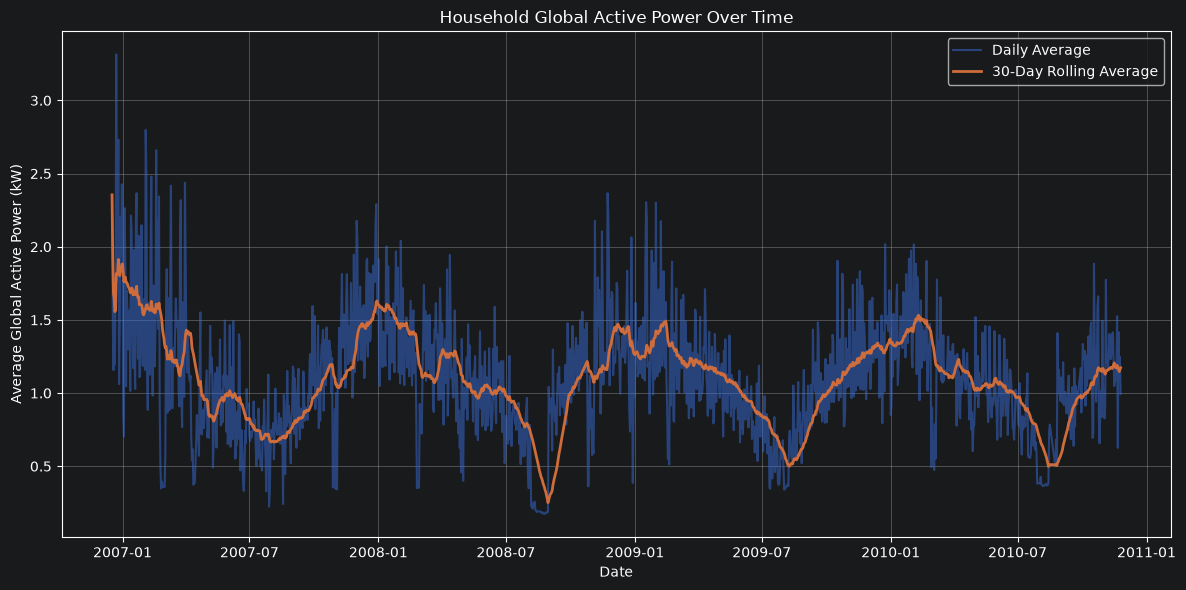

In [13]:
#2.4 Exploratory and Statistical Analysis - Long-term Daily Energy Consumption

daily_power_clean['Rolling_30D'] = (
    daily_power_clean['Global_active_power']
    .rolling(window=30, min_periods=1)
    .mean())

plt.figure(figsize=(12, 6))

plt.plot(
    daily_power_clean['Datetime'],
    daily_power_clean['Global_active_power'],
    label='Daily Average',
    alpha=0.5)

plt.plot(
    daily_power_clean['Datetime'],
    daily_power_clean['Rolling_30D'],
    label='30-Day Rolling Average',
    linewidth=2)

plt.title('Household Global Active Power Over Time')
plt.xlabel('Date')
plt.ylabel('Average Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

    Datetime  Global_active_power
0 2006-12-31             1.880110
1 2007-01-31             1.546060
2 2007-02-28             1.401130
3 2007-03-31             1.318649
4 2007-04-30             0.893465
----------------------------------------
(48, 2)


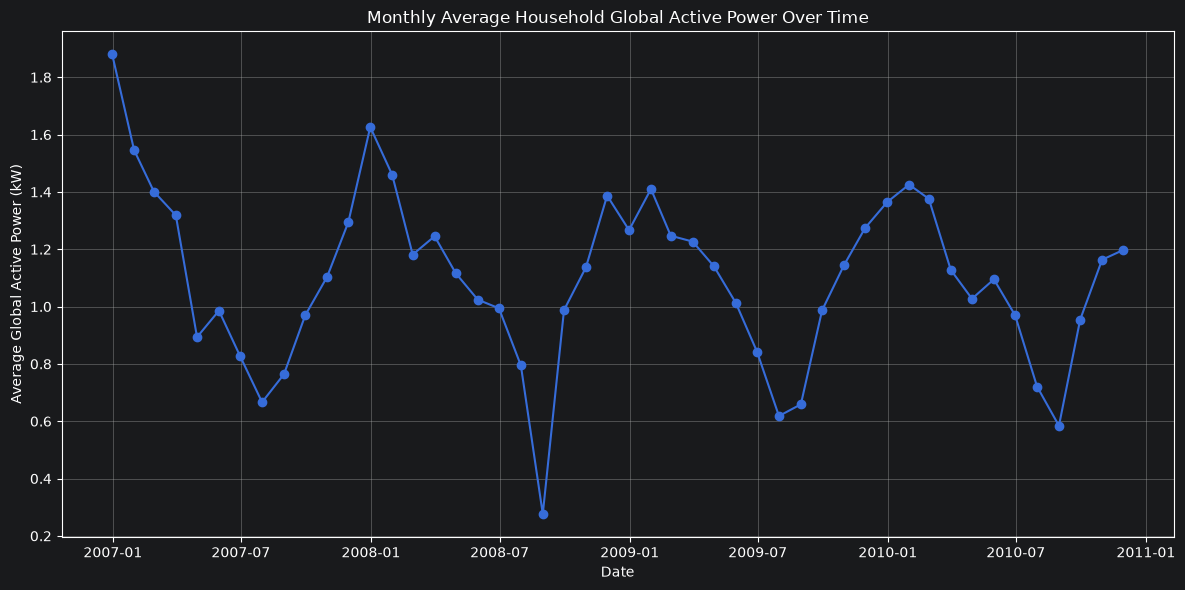

In [14]:
#2.5 Exploratory and Statistical Analysis - Monthly average Global Active Power over time

monthly_power = (
    daily_power_clean
    .set_index('Datetime')['Global_active_power']
    .resample('ME')
    .mean()
    .reset_index())

print(monthly_power.head())
print('-' * 40)
print(monthly_power.shape)

        #Monthly Analysis in plot

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_power['Datetime'],
    monthly_power['Global_active_power'],
    marker='o')

plt.title('Monthly Average Household Global Active Power Over Time')
plt.xlabel('Date')
plt.ylabel('Average Global Active Power (kW)')
plt.grid(True)
plt.tight_layout()
plt.show()

    Month  Global_active_power
0       1             1.472052
1       2             1.275572
2       3             1.263567
3       4             1.053958
4       5             1.007666
5       6             0.888459
6       7             0.693449
7       8             0.567759
8       9             0.981280
9      10             1.128386
10     11             1.318757
11     12             1.422105


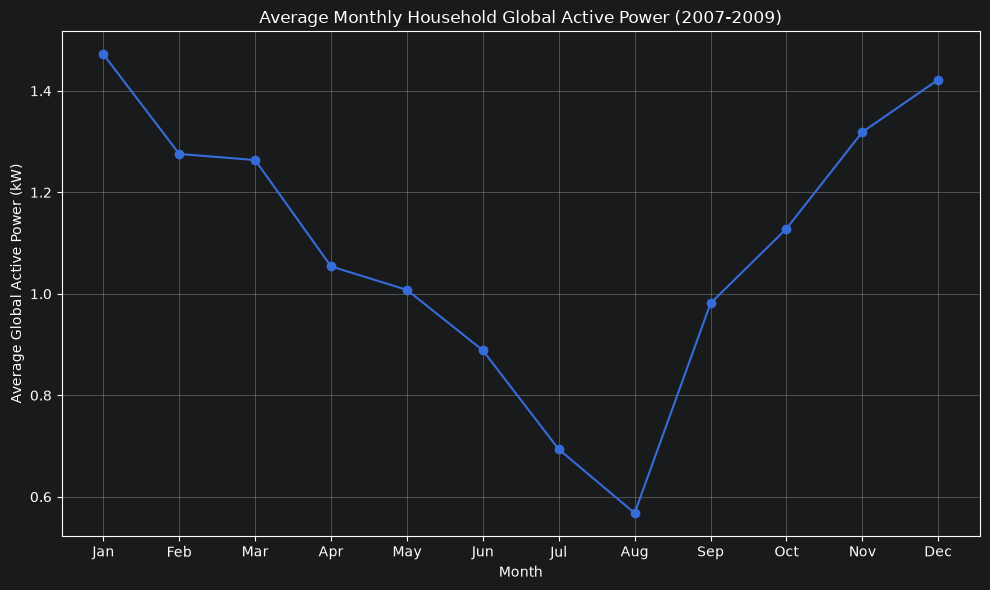

In [15]:
#2.6 Exploratory and Statistical Analysis - Typical Monthly Consumption Pattern

# Using complete years 2007-2009

seasonal_monthly = (
    df[df['Year'].isin([2007, 2008, 2009])]
    .groupby('Month')['Global_active_power']
    .mean()
    .reset_index())

print(seasonal_monthly)

# Using complete years 2007-2009 to plot them now

plt.figure(figsize=(10, 6))

plt.plot(
    seasonal_monthly['Month'],
    seasonal_monthly['Global_active_power'],
    marker='o')

plt.title('Average Monthly Household Global Active Power (2007-2009)')
plt.xlabel('Month')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

    Hour  Global_active_power
0      0             0.659434
1      1             0.539325
2      2             0.480621
3      3             0.444866
4      4             0.443847
5      5             0.453674
6      6             0.791600
7      7             1.502246
8      8             1.461016
9      9             1.331645
10    10             1.260627
11    11             1.245822
12    12             1.207075
13    13             1.144532
14    14             1.082839
15    15             0.990760
16    16             0.948905
17    17             1.055109
18    18             1.326451
19    19             1.733335
20    20             1.899064
21    21             1.877697
22    22             1.412615
23    23             0.902142


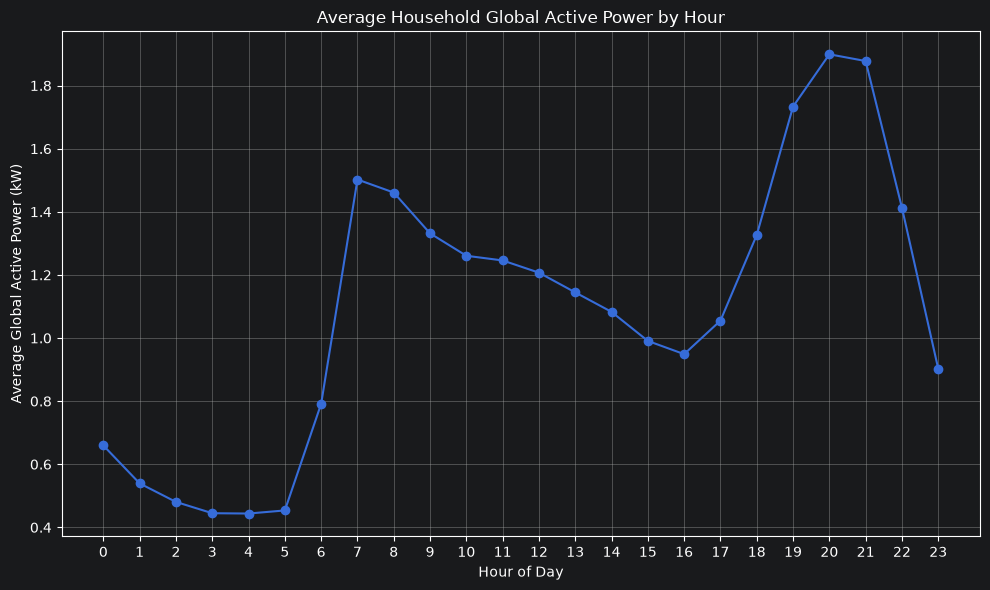

In [16]:
#2.7 Exploratory and Statistical Analysis - Typical Hourly Consumption Pattern

hourly_power = (
    df.groupby('Hour')['Global_active_power']
    .mean()
    .reset_index())

print(hourly_power)


#Plot the hourly consumption

plt.figure(figsize=(10, 6))

plt.plot(
    hourly_power['Hour'],
    hourly_power['Global_active_power'],
    marker='o')

plt.title('Average Household Global Active Power by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(range(24))
plt.grid(True)
plt.tight_layout()
plt.show()

Day
Monday       0.999546
Tuesday      1.069796
Wednesday    1.082588
Thursday     0.981809
Friday       1.043394
Saturday     1.248335
Sunday       1.220188
Name: Global_active_power, dtype: float64


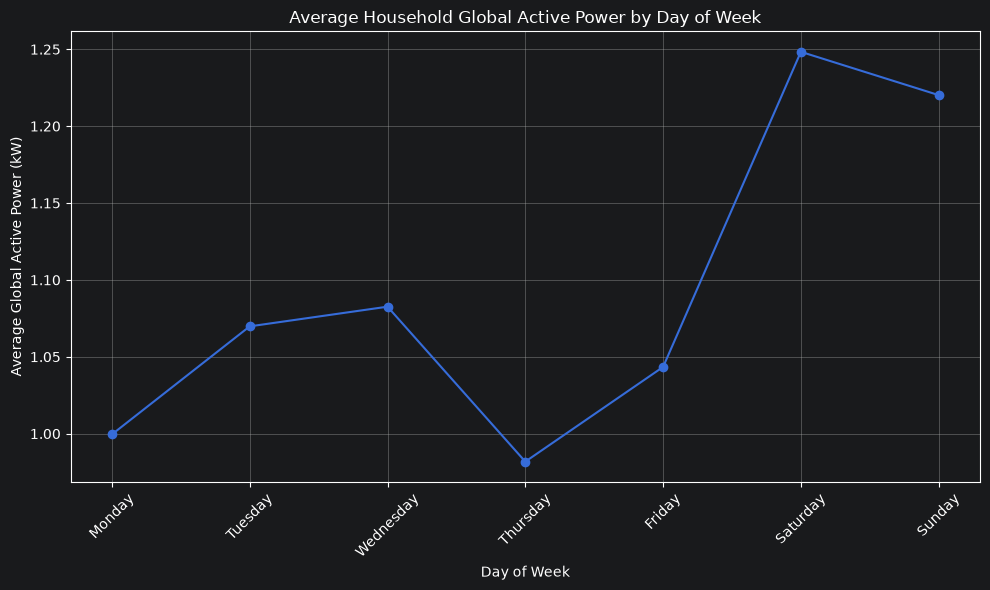

In [17]:
#2.8 Exploratory and Statistical Analysis - Average Consumption by Day of Week

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly_power = (
    df.groupby('Day')['Global_active_power']
    .mean()
    .reindex(day_order))

print(weekly_power)

#Plot

plt.figure(figsize=(10, 6))

plt.plot(
    weekly_power.index,
    weekly_power.values,
    marker='o')

plt.title('Average Household Global Active Power by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
#2.9 Exploratory and Statistical Analysis - Summary Statistics for Global Active Power

power_summary = df['Global_active_power'].describe()

print(power_summary)
print('-' * 40)

print('Median:', df['Global_active_power'].median())
print('Standard Deviation:', df['Global_active_power'].std())

count    2.049280e+06
mean     1.091615e+00
std      1.057294e+00
min      7.600000e-02
25%      3.080000e-01
50%      6.020000e-01
75%      1.528000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64
----------------------------------------
Median: 0.602
Standard Deviation: 1.0572941610939826


In [19]:
#2.10 Exploratory and Statistical Analysis - Identifying unusual daily consumption using the IQR method

Q1 = daily_power_clean['Global_active_power'].quantile(0.25)
Q3 = daily_power_clean['Global_active_power'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

daily_anomalies = daily_power_clean[
    (daily_power_clean['Global_active_power'] < lower_limit) |
    (daily_power_clean['Global_active_power'] > upper_limit)]

print('Q1:', round(Q1, 3))
print('Q3:', round(Q3, 3))
print('IQR:', round(IQR, 3))
print('Lower Limit:', round(lower_limit, 3))
print('Upper Limit:', round(upper_limit, 3))

print('-' * 40)
print('Number of unusual days:', len(daily_anomalies))
print('-' * 40)

print(
    daily_anomalies
    .sort_values('Global_active_power', ascending=False)
    .head(10))

Q1: 0.819
Q3: 1.319
IQR: 0.5
Lower Limit: 0.069
Upper Limit: 2.069
----------------------------------------
Number of unusual days: 32
----------------------------------------
      Datetime  Global_active_power  Rolling_30D
7   2006-12-23             3.314851     1.817457
49  2007-02-03             2.798418     1.579783
10  2006-12-26             2.732021     1.913000
64  2007-02-18             2.659557     1.607973
50  2007-02-04             2.497181     1.600213
57  2007-02-11             2.480019     1.626399
105 2007-03-31             2.437160     1.350624
15  2006-12-31             2.426525     1.880110
85  2007-03-11             2.417108     1.290329
708 2008-11-23             2.366452     1.188625


                       Global_active_power  Global_reactive_power  Voltage  \
Global_active_power                  1.000                  0.247   -0.400   
Global_reactive_power                0.247                  1.000   -0.112   
Voltage                             -0.400                 -0.112    1.000   
Global_intensity                     0.999                  0.266   -0.411   
Sub_metering_1                       0.484                  0.123   -0.196   
Sub_metering_2                       0.435                  0.139   -0.167   
Sub_metering_3                       0.639                  0.090   -0.268   

                       Global_intensity  Sub_metering_1  Sub_metering_2  \
Global_active_power               0.999           0.484           0.435   
Global_reactive_power             0.266           0.123           0.139   
Voltage                          -0.411          -0.196          -0.167   
Global_intensity                  1.000           0.489           0.440   


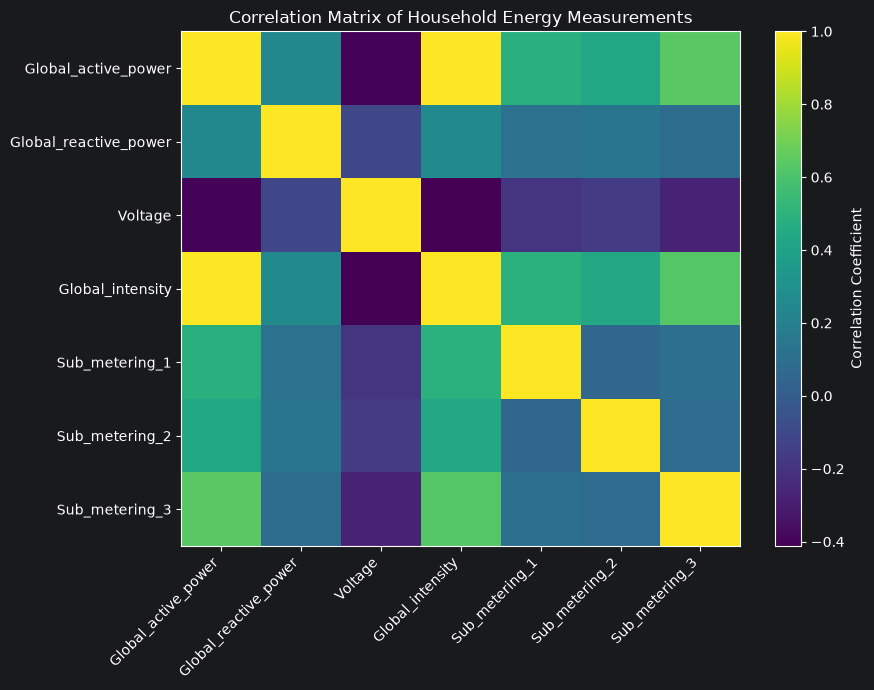

In [20]:
#2.11 Exploratory and Statistical Analysis - Correlation Analysis

correlation_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3']

correlation_matrix = df[correlation_cols].corr()

print(correlation_matrix.round(3))
print('-' * 100)

    # Correlation Matrix Visualization

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect='auto')

plt.colorbar(label='Correlation Coefficient')

plt.xticks(
    range(len(correlation_cols)),
    correlation_cols,
    rotation=45,
    ha='right')

plt.yticks(
    range(len(correlation_cols)),
    correlation_cols)

plt.title('Correlation Matrix of Household Energy Measurements')
plt.tight_layout()
plt.show()

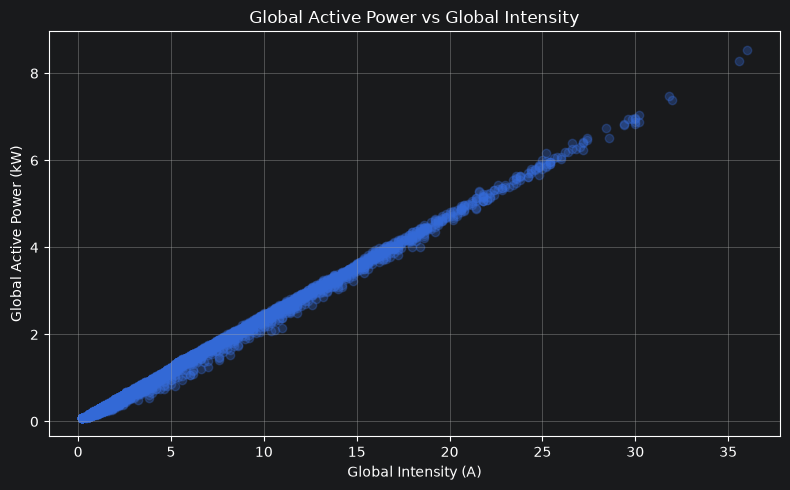

--------------------------------------------------------------------------------------------------------------------------------------------


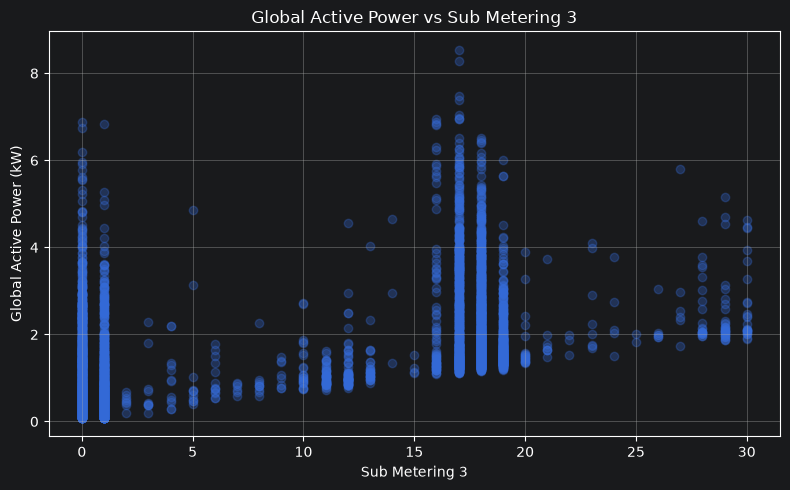

In [21]:
#2.12 Exploratory and Statistical Analysis - Scatter plots for strongest relationships

sample_data = df.sample(
    n=10000,
    random_state=42)

# Global Active Power vs Global Intensity

plt.figure(figsize=(8, 5))

plt.scatter(
    sample_data['Global_intensity'],
    sample_data['Global_active_power'],
    alpha=0.3)

plt.title('Global Active Power vs Global Intensity')
plt.xlabel('Global Intensity (A)')
plt.ylabel('Global Active Power (kW)')
plt.grid(True)
plt.tight_layout()
plt.show()

print('-' * 140)

# Global Active Power vs Sub Metering 3

plt.figure(figsize=(8, 5))

plt.scatter(
    sample_data['Sub_metering_3'],
    sample_data['Global_active_power'],
    alpha=0.3)

plt.title('Global Active Power vs Sub Metering 3')
plt.xlabel('Sub Metering 3')
plt.ylabel('Global Active Power (kW)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# 3.1 Predictive Modelling - Prepare data

predictor_cols = [
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3']

X = df[predictor_cols]
y = df['Global_active_power']

# Chronological 80/20 split
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print('Training observations:', len(X_train))
print('Testing observations:', len(X_test))

print('-' * 40)

print(
    'Training period:',
    df['Datetime'].iloc[0],
    'to',
    df['Datetime'].iloc[split_index - 1]
)

print(
    'Testing period:',
    df['Datetime'].iloc[split_index],
    'to',
    df['Datetime'].iloc[-1]
)

Training observations: 1639424
Testing observations: 409856
----------------------------------------
Training period: 2006-12-16 17:24:00 to 2010-02-05 04:28:00
Testing period: 2010-02-05 04:29:00 to 2010-11-26 21:02:00


In [23]:
# 3.2 Predictive Modelling - Linear Regression Model (6 variables)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create and train model
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Predictions on test data
y_pred = linear_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('Linear Regression Model')
print('-' * 40)
print('MAE:', round(mae, 4))
print('RMSE:', round(rmse, 4))
print('R²:', round(r2, 4))

Linear Regression Model
----------------------------------------
MAE: 0.0245
RMSE: 0.0397
R²: 0.998


In [24]:
# 3.3 Predictive Modelling - Simple Linear Regression using Global Intensity only

X_train_simple = X_train[['Global_intensity']]
X_test_simple = X_test[['Global_intensity']]

simple_model = LinearRegression()

simple_model.fit(X_train_simple, y_train)

y_pred_simple = simple_model.predict(X_test_simple)

# Evaluation
mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)

print('Simple Linear Regression Model')
print('-' * 40)
print('MAE:', round(mae_simple, 4))
print('RMSE:', round(rmse_simple, 4))
print('R²:', round(r2_simple, 4))

Simple Linear Regression Model
----------------------------------------
MAE: 0.0337
RMSE: 0.0493
R²: 0.997


In [25]:
# 3.4 Predictive Modelling - Standardised coefficients for predictor contribution

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

scaled_model = LinearRegression()

scaled_model.fit(X_train_scaled, y_train)

coefficient_table = pd.DataFrame({
    'Predictor': predictor_cols,
    'Standardised_Coefficient': scaled_model.coef_})

coefficient_table['Absolute_Coefficient'] = (
    coefficient_table['Standardised_Coefficient'].abs())

coefficient_table = coefficient_table.sort_values(
    'Absolute_Coefficient',
    ascending=False)

print(coefficient_table)

               Predictor  Standardised_Coefficient  Absolute_Coefficient
2       Global_intensity                  1.093655              1.093655
0  Global_reactive_power                 -0.019288              0.019288
5         Sub_metering_3                  0.018261              0.018261
1                Voltage                  0.014838              0.014838
4         Sub_metering_2                 -0.003012              0.003012
3         Sub_metering_1                 -0.000993              0.000993


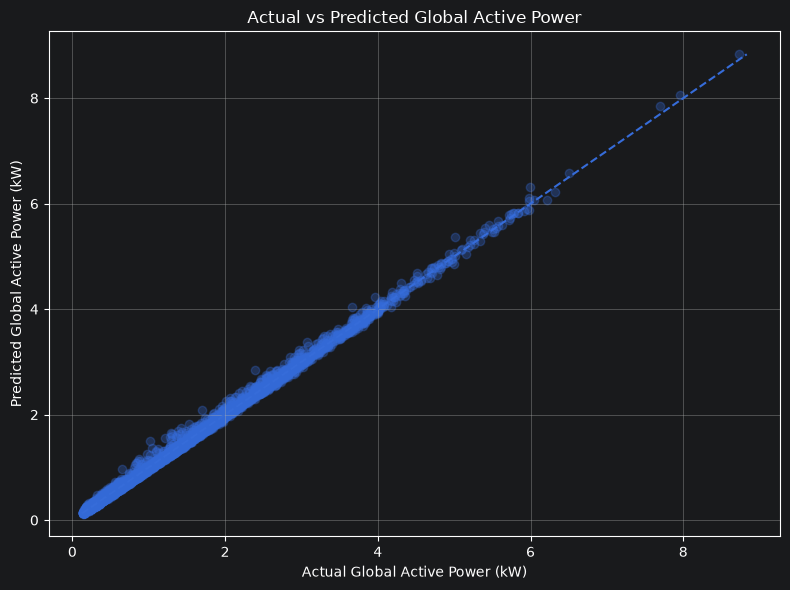

In [26]:
# 3.5 Predictive Modelling - Actual vs Predicted Global Active Power

# Select 10,000 evenly spaced observations
plot_indices = np.linspace(
    0,
    len(y_test) - 1,
    10000,
    dtype=int)

actual_plot = y_test.iloc[plot_indices]
predicted_plot = y_pred[plot_indices]

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_plot,
    predicted_plot,
    alpha=0.3)

# Perfect prediction reference line
min_value = min(actual_plot.min(), predicted_plot.min())
max_value = max(actual_plot.max(), predicted_plot.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    '--')

plt.title('Actual vs Predicted Global Active Power')
plt.xlabel('Actual Global Active Power (kW)')
plt.ylabel('Predicted Global Active Power (kW)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
# 3.6 Predictive Modelling - Model Performance Comparison

model_comparison = pd.DataFrame({
    'Model': [
        'Full Linear Regression (6 predictors)',
        'Simple Linear Regression (Global_intensity only)'
    ],
    'MAE': [
        mae,
        mae_simple
    ],
    'RMSE': [
        rmse,
        rmse_simple
    ],
    'R2': [
        r2,
        r2_simple
    ]
})

print(model_comparison.round(4))
print('-'*100)

#Error increase when we simplify
mae_increase = ((mae_simple - mae) / mae) * 100
rmse_increase = ((rmse_simple - rmse) / rmse) * 100

print('MAE increase with simple model:', round(mae_increase, 2), '%')
print('RMSE increase with simple model:', round(rmse_increase, 2), '%')

                                              Model     MAE    RMSE     R2
0             Full Linear Regression (6 predictors)  0.0245  0.0397  0.998
1  Simple Linear Regression (Global_intensity only)  0.0337  0.0493  0.997
----------------------------------------------------------------------------------------------------
MAE increase with simple model: 37.75 %
RMSE increase with simple model: 23.96 %


In [28]:
# 4.1 Customer Consumption Segmentation - Prepare hourly data for clustering

clustering_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3']

hourly_cluster_data = (
    df.set_index('Datetime')[clustering_cols]
      .resample('h')
      .mean()
      .dropna()
      .reset_index())

print('Hourly observations:', len(hourly_cluster_data))
print()
print(hourly_cluster_data.head())
print()
print(hourly_cluster_data[clustering_cols].describe().round(3))

Hourly observations: 34168

             Datetime  Global_active_power  Global_reactive_power     Voltage  \
0 2006-12-16 17:00:00             4.222889               0.229000  234.643889   
1 2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2 2006-12-16 19:00:00             3.400233               0.085233  233.232500   
3 2006-12-16 20:00:00             3.268567               0.075100  234.071500   
4 2006-12-16 21:00:00             3.056467               0.076667  237.158667   

   Sub_metering_1  Sub_metering_2  Sub_metering_3  
0             0.0        0.527778       16.861111  
1             0.0        6.716667       16.866667  
2             0.0        1.433333       16.683333  
3             0.0        0.000000       16.783333  
4             0.0        0.416667       17.216667  

       Global_active_power  Global_reactive_power    Voltage  Sub_metering_1  \
count            34168.000              34168.000  34168.000       34168.000   
mean        

In [29]:
# 4.2 Customer Consumption Segmentation - Standardisation and selection of clusters

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Prepare clustering features
X_cluster = hourly_cluster_data[clustering_cols]

# Standardize variables
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Test k 2 to 8
k_values = range(2, 9)

inertia_values = []
silhouette_values = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    cluster_labels = kmeans.fit_predict(X_cluster_scaled)

    inertia_values.append(kmeans.inertia_)

    silhouette = silhouette_score(
        X_cluster_scaled,
        cluster_labels,
        sample_size=10000,
        random_state=42)

    silhouette_values.append(silhouette)

    print(
        'k =', k,
        '| Inertia =', round(kmeans.inertia_, 2),
        '| Silhouette =', round(silhouette, 4))

k = 2 | Inertia = 146593.38 | Silhouette = 0.3788
k = 3 | Inertia = 117126.92 | Silhouette = 0.3739
k = 4 | Inertia = 95827.52 | Silhouette = 0.3824
k = 5 | Inertia = 84661.79 | Silhouette = 0.2672
k = 6 | Inertia = 76379.64 | Silhouette = 0.2685
k = 7 | Inertia = 69273.33 | Silhouette = 0.2741
k = 8 | Inertia = 64261.12 | Silhouette = 0.2782


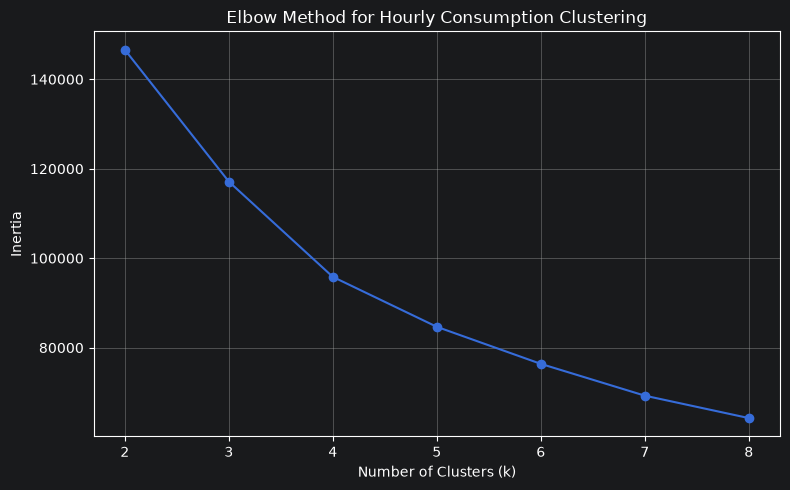

In [30]:
# 4.3 Customer Consumption Segmentation - Elbow Method plot

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker='o')

plt.title('Elbow Method for Hourly Consumption Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

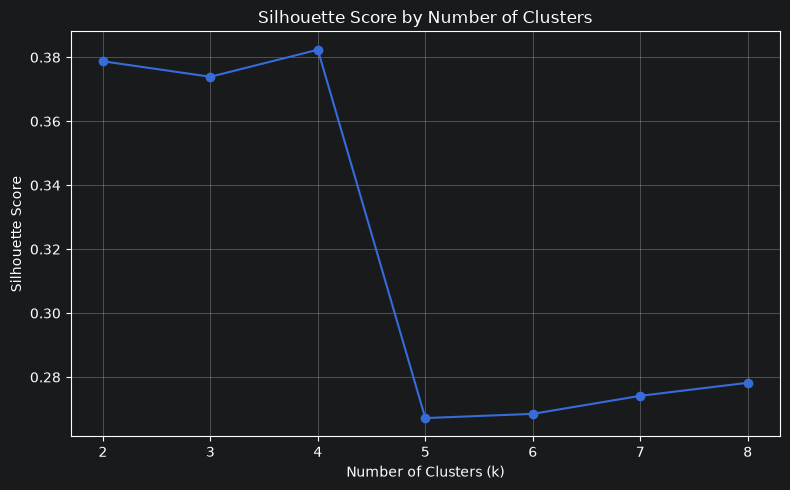

In [31]:
# 4.4 Customer Consumption Segmentation - Silhouette Scores

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_values,
    marker='o')

plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
# 4.5 Customer Consumption Segmentation - Final KMeans Model with k = 4

final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10)

hourly_cluster_data['Cluster'] = final_kmeans.fit_predict(
    X_cluster_scaled)

# Cluster sizes
cluster_sizes = hourly_cluster_data['Cluster'].value_counts().sort_index()

print('Cluster Sizes')
print('-' * 40)
print(cluster_sizes)

print('\nCluster Percentages')
print('-' * 40)
print((cluster_sizes / len(hourly_cluster_data) * 100).round(2))

# Average characteristics of each cluster
cluster_profile = (
    hourly_cluster_data
    .groupby('Cluster')[clustering_cols]
    .mean()
    .round(3))

print('\nAverage Characteristics by Cluster')
print('-' * 40)
print(cluster_profile)

Cluster Sizes
----------------------------------------
Cluster
0     2814
1     9310
2     1117
3    20927
Name: count, dtype: int64

Cluster Percentages
----------------------------------------
Cluster
0     8.24
1    27.25
2     3.27
3    61.25
Name: count, dtype: float64

Average Characteristics by Cluster
----------------------------------------
         Global_active_power  Global_reactive_power  Voltage  Sub_metering_1  \
Cluster                                                                        
0                      2.369                  0.187  238.864          10.725   
1                      1.721                  0.118  239.680           0.201   
2                      2.992                  0.195  238.543           2.650   
3                      0.538                  0.114  241.744           0.158   

         Sub_metering_2  Sub_metering_3  
Cluster                                  
0                 1.188          11.726  
1                 0.739          15.550  

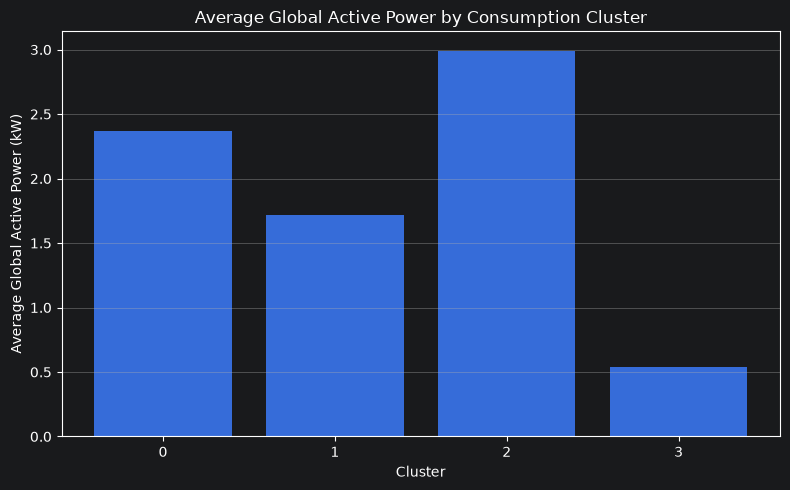

In [33]:
# 4.6 Customer Consumption Segmentation - Average Global Active Power by Cluster

cluster_avg_power = (
    hourly_cluster_data
    .groupby('Cluster')['Global_active_power']
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_avg_power.index.astype(str),
    cluster_avg_power.values)

plt.title('Average Global Active Power by Consumption Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Global Active Power (kW)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [34]:
# 4.7 Customer Consumption Segmentation - Cluster distribution by hour of day

hourly_cluster_data['Hour'] = hourly_cluster_data['Datetime'].dt.hour

cluster_hour_profile = pd.crosstab(
    hourly_cluster_data['Hour'],
    hourly_cluster_data['Cluster'],
    normalize='index') * 100

print(cluster_hour_profile.round(2))

Cluster      0      1     2      3
Hour                              
0         2.31  10.45  0.63  86.61
1         1.62   7.87  0.21  90.31
2         0.84   5.97  0.00  93.19
3         0.42   3.93  0.07  95.58
4         0.28   4.50  0.00  95.22
5         0.21   5.70  0.00  94.09
6         0.28  17.52  0.00  82.20
7         2.74  58.37  0.56  38.33
8        12.73  57.52  1.97  27.78
9        13.71  56.05  1.76  28.48
10        8.16  54.57  3.66  33.61
11        9.85  46.34  4.29  39.52
12        9.70  37.69  5.49  47.12
13        8.50  32.96  7.59  50.95
14        9.69  26.12  7.58  56.60
15        9.35  22.00  5.76  62.90
16        5.83  20.38  5.34  68.45
17        4.85  23.26  5.76  66.13
18        9.20  26.40  5.06  59.34
19       17.10  32.45  6.17  44.29
20       22.21  35.53  6.24  36.02
21       23.39  31.30  5.53  39.78
22       19.14  21.88  3.02  55.96
23        5.40  15.29  1.75  77.56


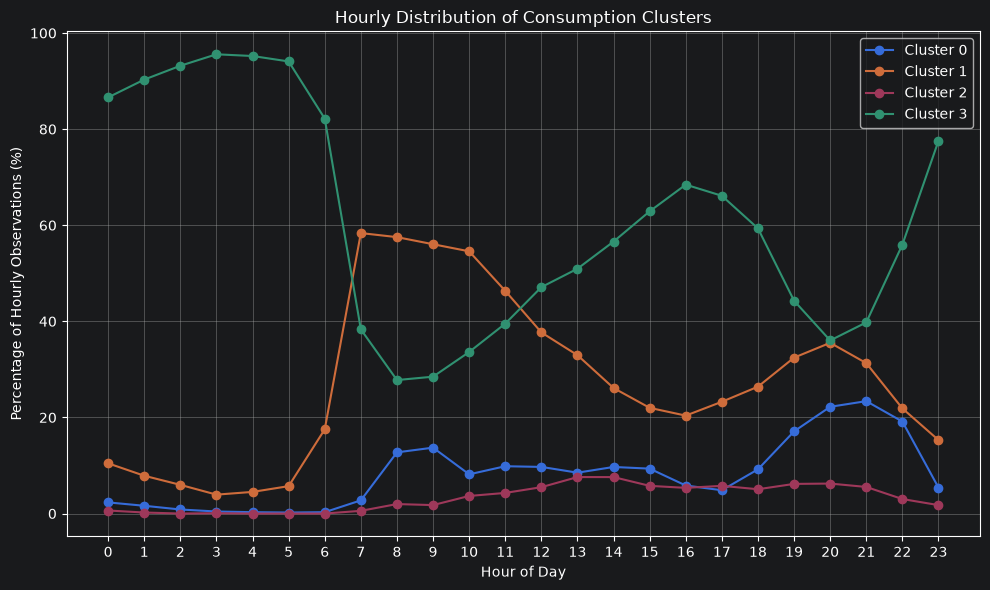

In [35]:
# 4.8 Customer Consumption Segmentation - Plot

plt.figure(figsize=(10, 6))

for cluster in cluster_hour_profile.columns:
    plt.plot(
        cluster_hour_profile.index,
        cluster_hour_profile[cluster],
        marker='o',
        label=f'Cluster {cluster}')

plt.title('Hourly Distribution of Consumption Clusters')
plt.xlabel('Hour of Day')
plt.ylabel('Percentage of Hourly Observations (%)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

   Global_active_power  Global_reactive_power  Voltage  Sub_metering_1  \
0                 1.42                   0.94    -0.66            2.71   
1                 0.70                  -0.08    -0.39           -0.26   
2                 2.12                   1.06    -0.77            0.43   
3                -0.62                  -0.15     0.30           -0.27   

   Sub_metering_2  Sub_metering_3  
0           -0.03            0.72  
1           -0.13            1.24  
2            4.90            0.55  
3           -0.20           -0.68  


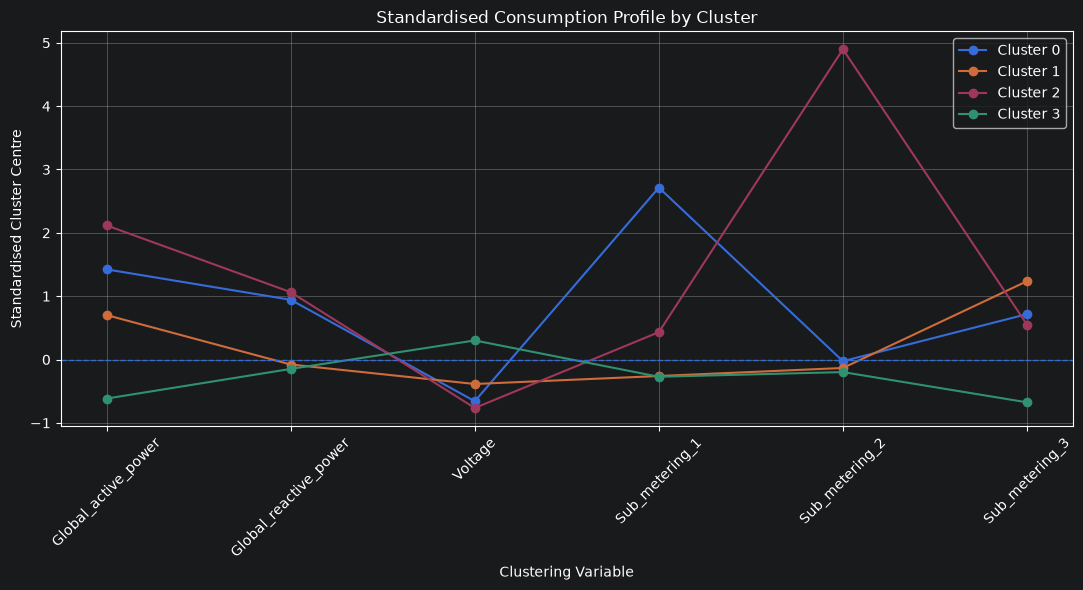

In [36]:
# 4.9 Customer Consumption Segmentation - Standardised profile of each cluster

cluster_centres = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=clustering_cols)

print(cluster_centres.round(2))

plt.figure(figsize=(11, 6))

for cluster in cluster_centres.index:
    plt.plot(
        clustering_cols,
        cluster_centres.loc[cluster],
        marker='o',
        label=f'Cluster {cluster}')

plt.axhline(0, linestyle='--', linewidth=1)

plt.title('Standardised Consumption Profile by Cluster')
plt.xlabel('Clustering Variable')
plt.ylabel('Standardised Cluster Centre')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
# 4.10 Customer Consumption Segmentation - Final cluster summary table

cluster_summary = cluster_profile.copy()

cluster_summary.insert(
    0,
    'Observations',
    cluster_sizes)

cluster_summary.insert(
    1,
    'Percentage',
    (cluster_sizes / len(hourly_cluster_data) * 100).round(2))

print(cluster_summary)

         Observations  Percentage  Global_active_power  Global_reactive_power  \
Cluster                                                                         
0                2814        8.24                2.369                  0.187   
1                9310       27.25                1.721                  0.118   
2                1117        3.27                2.992                  0.195   
3               20927       61.25                0.538                  0.114   

         Voltage  Sub_metering_1  Sub_metering_2  Sub_metering_3  
Cluster                                                           
0        238.864          10.725           1.188          11.726  
1        239.680           0.201           0.739          15.550  
2        238.543           2.650          21.835          10.506  
3        241.744           0.158           0.466           1.490  
